# Lee-Carter in R: an independent check and a second model for the mortality trend

This notebook re-estimates the Poisson Lee-Carter model of the mortality notebook with **R**, starting again from the official
Eurostat files, and compares the results with the Python/C++ package `longevity_risk`:

| Quantity | R implementation | Python notebook |
| --- | --- | --- |
| Deaths and central exposures, Italy, men, ages 50-99 | own parser of the Eurostat JSON-stat API | `lee_carter_mortality_projection` |
| Poisson Lee-Carter (Brouhns, Denuit and Vermunt, 2002), pandemic years excluded | `gnm` generalised nonlinear model | same notebook |
| Random walk with drift for $k_t$ | direct formulas | same notebook |
| Period life expectancy at 65 | life table from the crude rates | same notebook |
| Alternative time-series model for $k_t$ | `forecast::auto.arima` | new in R |

**Requirements.** R 4.2 or later with the packages in `r/install_packages.R` and the IRkernel (see the README). The comparison cells
call the Python package if it is installed (`PYTHON` environment variable, `.venv` in the repository or `python3` on the PATH);
otherwise they are skipped. Data are downloaded into `data/raw/r/`. The random seed of `gnm` is fixed at 20240101.

In [1]:
suppressPackageStartupMessages({
  library(jsonlite)
  library(ggplot2)
  library(gnm)
  library(forecast)
})
options(width = 120, repr.plot.width = 10, repr.plot.height = 4.6, repr.plot.res = 110, scipen = 6)

# Repository root: the folder that contains scripts/longevity_risk.
find_root <- function() {
  d <- normalizePath(getwd())
  repeat {
    if (dir.exists(file.path(d, "scripts", "longevity_risk"))) return(d)
    parent <- dirname(d)
    if (parent == d) stop("run the notebook inside the repository")
    d <- parent
  }
}
ROOT <- find_root()
CACHE <- file.path(ROOT, "data", "raw", "r")   # ignored by Git
dir.create(CACHE, recursive = TRUE, showWarnings = FALSE)

cached_download <- function(url, name) {
  path <- file.path(CACHE, name)
  if (!file.exists(path)) download.file(url, path, quiet = TRUE, mode = "wb")
  path
}

# Results of the Python/C++ engine for the comparison. The code is run with the interpreter in the
# PYTHON environment variable, or .venv in the repository, or python3 on the PATH; it must print JSON.
python_json <- function(code) {
  candidates <- c(Sys.getenv("PYTHON"), file.path(ROOT, ".venv", "bin", "python"),
                  file.path(ROOT, ".venv", "Scripts", "python.exe"), Sys.which("python3"), Sys.which("python"))
  candidates <- candidates[nzchar(candidates) & file.exists(candidates)]
  if (length(candidates) == 0) { message("Python not found: comparison skipped"); return(NULL) }
  script <- tempfile(fileext = ".py")
  writeLines(c("import json, os, sys", sprintf("os.chdir(%s)", deparse(ROOT)), code), script)
  out <- suppressWarnings(system2(candidates[1], script, stdout = TRUE, stderr = FALSE))
  if (!is.null(attr(out, "status")) || length(out) == 0) {
    message("the Python package longevity_risk is not available: comparison skipped"); return(NULL)
  }
  fromJSON(paste(out, collapse = "\n"))
}

compare <- function(r, py, label = names(r)) {
  data.frame(quantity = label, R = signif(r, 10), Python = signif(py, 10),
             `abs. difference` = signif(abs(r - py), 3), check.names = FALSE, row.names = NULL)
}

COLORS <- c("#2a78d6", "#eb6834", "#1baf7a", "#eda100")
theme_set(theme_minimal(base_size = 12) +
          theme(panel.grid.minor = element_blank(), plot.title.position = "plot",
                plot.title = element_text(face = "bold"), legend.position = "top"))
cat(R.version.string, "| repository:", basename(ROOT), "\n")

# Eurostat dissemination API (JSON-stat 2.0), parsed into a long data frame.
eurostat <- function(dataset, ...) {
  filters <- list(...)
  query <- c("format=JSON", "lang=EN",
             unlist(Map(function(k, v) paste0(k, "=", v), rep(names(filters), lengths(filters)), unlist(filters))))
  url <- paste0("https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/", dataset, "?",
                paste(query, collapse = "&"))
  tag <- gsub("[^A-Za-z0-9]+", "_", paste(query[-(1:2)], collapse = "_"))
  js <- fromJSON(cached_download(url, paste0(dataset, "_", tag, ".json")), simplifyVector = FALSE)
  ids <- unlist(js$id); sizes <- unlist(js$size)
  labels <- lapply(ids, function(d) {
    idx <- js$dimension[[d]]$category$index
    if (is.null(names(idx))) unlist(idx) else names(idx)[order(unlist(idx))]
  })
  values <- js$value
  if (is.null(names(values))) {
    keep <- !vapply(values, is.null, logical(1))
    pos <- which(keep) - 1; v <- as.numeric(unlist(values[keep]))
  } else {
    pos <- as.integer(names(values)); v <- as.numeric(unlist(values))
  }
  strides <- rev(cumprod(c(1, rev(sizes)))[seq_along(sizes)])
  out <- as.data.frame(setNames(lapply(seq_along(ids), function(i) labels[[i]][(pos %/% strides[i]) %% sizes[i] + 1]), ids),
                       stringsAsFactors = FALSE)
  out$value <- v
  out$year <- as.integer(substr(out$time, 1, 4))
  out
}

AGES <- 50:99
PANDEMIC <- 2020:2022
FIRST_YEAR <- 1975

R version 4.3.3 (2024-02-29) | repository: Actuarial-mathematics 


## 1. Deaths and exposures

Deaths by single age (`demo_magec`) and population on 1 January (`demo_pjan`); the central exposure of year $t$ is the average of the
populations on 1 January of $t$ and $t+1$, so the last usable year is the one before the latest population figure.

In [2]:
to_age <- function(code) ifelse(code == "Y_LT1", 0L, suppressWarnings(as.integer(sub("^Y", "", code))))
age_year <- function(frame) {
  frame$age_num <- to_age(frame$age)
  frame <- frame[!is.na(frame$age_num), ]
  tapply(frame$value, list(frame$age_num, frame$year), sum)
}
D_all <- age_year(eurostat("demo_magec", geo = "IT", sex = "M", unit = "NR"))
P_all <- age_year(eurostat("demo_pjan", geo = "IT", sex = "M", unit = "NR"))
years <- as.integer(colnames(D_all))
years <- years[years >= FIRST_YEAR & as.character(years) %in% colnames(P_all) & as.character(years + 1) %in% colnames(P_all)]
D <- D_all[as.character(AGES), as.character(years)]
E <- 0.5 * (P_all[as.character(AGES), as.character(years)] + P_all[as.character(AGES), as.character(years + 1)])
complete <- colSums(is.na(D)) == 0 & colSums(is.na(E)) == 0 & colSums(E <= 0, na.rm = TRUE) == 0
D <- D[, complete]; E <- E[, complete]; years <- years[complete]
cat(sprintf("Men, ages %d-%d, years %d-%d: %s deaths\n", min(AGES), max(AGES), min(years), max(years), format(sum(D), big.mark = ",")))

Men, ages 50-99, years 1992-2024: 9,135,893 deaths


In [3]:
py <- python_json('
import numpy as np
from longevity_risk import data, lee_carter as lc, life_table as lt
D, E = data.load_deaths_exposures("IT", "M", range(50, 100))
keep = [y for y in D.columns if y >= 1975]
D, E = D.loc[:, keep], E.loc[:, keep]
fit = lc.fit_poisson(D, E, fit_years=[y for y in keep if y not in (2020, 2021, 2022)])
rw = lc.RandomWalkDrift.from_kt(fit.years, fit.kt)
e65 = lt.period_life_expectancy((D / E).loc[65:99, keep[-1]].to_numpy())
clean = lambda a: [None if not np.isfinite(v) else float(v) for v in a]
print(json.dumps({"years": [int(y) for y in D.columns], "D": D.to_numpy().tolist(), "E": E.to_numpy().tolist(),
                  "ax": clean(fit.ax), "bx": clean(fit.bx), "kt": clean(fit.kt), "deviance": fit.deviance,
                  "drift": rw.drift, "sigma": rw.sigma, "drift_se": rw.drift_se, "e65": e65}))
')
if (!is.null(py)) {
  cat("Same years:", identical(as.integer(py$years), years), "\n")
  cat(sprintf("Deaths: max abs. difference %g; exposures: max abs. difference %g\n",
              max(abs(D - py$D)), max(abs(E - py$E))))
}

Same years: TRUE 
Deaths: max abs. difference 0; exposures: max abs. difference 0


## 2. Poisson Lee-Carter with `gnm`

$D_{x,t} \\sim \\text{Poisson}(E_{x,t}\\, e^{a_x + b_x k_t})$, fitted as a generalised nonlinear model with the multiplicative term
`Mult(age, year)`; the parameters are normalised afterwards to $\\sum_x b_x = 1$ and $\\sum_t k_t = 0$ over the fitted years, the
convention of the Python package. The pandemic years 2020-2022 are excluded from the fit.

In [4]:
long <- data.frame(age = rep(AGES, times = length(years)), year = rep(years, each = length(AGES)),
                   D = as.vector(D), E = as.vector(E))
fit_data <- subset(long, !(year %in% PANDEMIC))
fit_data$age_f <- factor(fit_data$age); fit_data$year_f <- factor(fit_data$year)
set.seed(20240101)
lc_fit <- gnm(D ~ -1 + age_f + Mult(age_f, year_f), offset = log(E), family = poisson, data = fit_data,
              verbose = FALSE, iterMax = 500)
cf <- coef(lc_fit)
a <- cf[paste0("age_f", AGES)]
b <- cf[grep("^Mult\\(\\., year_f\\)\\.age_f", names(cf))]
k <- cf[grep("^Mult\\(age_f, \\.\\)\\.year_f", names(cf))]
fit_years <- as.integer(sub(".*year_f", "", names(k)))
s <- sum(b); b <- b / s; k <- k * s
a <- a + b * mean(k); k <- k - mean(k)
cat(sprintf("gnm: converged %s, deviance %.1f on %d degrees of freedom\n", lc_fit$converged, deviance(lc_fit), df.residual(lc_fit)))
if (!is.null(py)) {
  py_k <- unlist(lapply(py$kt, function(v) if (is.null(v)) NA else v))[match(fit_years, py$years)]
  data.frame(quantity = c("a(x), 50 ages", "b(x), 50 ages", "k(t), fitted years", "Poisson deviance"),
             `max abs. difference R vs Python` = signif(c(max(abs(a - py$ax)), max(abs(b - py$bx)), max(abs(k - py_k)),
                                                         abs(deviance(lc_fit) - py$deviance)), 3), check.names = FALSE)
}

gnm: converged TRUE, deviance 11868.5 on 1372 degrees of freedom


quantity,max abs. difference R vs Python
<chr>,<dbl>
"a(x), 50 ages",1.11e-10
"b(x), 50 ages",5.17e-11
"k(t), fitted years",5.86e-08
Poisson deviance,4.18e-11


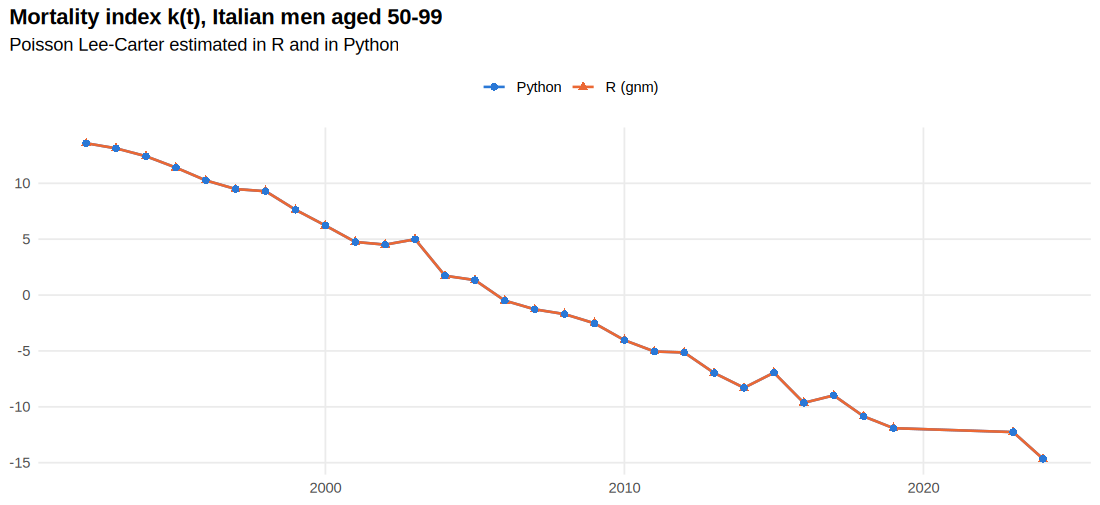

In [5]:
if (!is.null(py)) {
  plot_k <- data.frame(year = rep(fit_years, 2), k = c(k, py_k), source = rep(c("R (gnm)", "Python"), each = length(k)))
  ggplot(plot_k, aes(year, k, colour = source, shape = source)) + geom_line(linewidth = 0.8) + geom_point(size = 2) +
    scale_colour_manual(values = COLORS[1:2]) +
    labs(title = "Mortality index k(t), Italian men aged 50-99", subtitle = "Poisson Lee-Carter estimated in R and in Python",
         x = NULL, y = NULL, colour = NULL, shape = NULL)
}

## 3. Random walk with drift and life expectancy at 65

With the pandemic years missing, an increment over $g$ years is treated as $N(g\\,d, g\\,\\sigma^2)$: $d = (k_{last} - k_{first})/(t_{last} - t_{first})$
and $\\sigma^2 = \\sum (\\Delta k - g\\,d)^2/g \\,/\\,(n-1)$. The period life expectancy at 65 uses ages 65-99 with the last age as an open group.

In [6]:
gaps <- diff(fit_years); inc <- diff(k)
drift <- (tail(k, 1) - k[1]) / (tail(fit_years, 1) - fit_years[1])
sigma <- sqrt(sum((inc - gaps * drift)^2 / gaps) / (length(inc) - 1))
period_e <- function(m) {
  q <- 1 - exp(-m[-length(m)])
  l <- c(1, cumprod(1 - q))
  sum(l[-length(l)] * q / m[-length(m)]) + tail(l, 1) / tail(m, 1)
}
last <- as.character(max(years))
e65 <- period_e((D / E)[as.character(65:99), last])
r_values <- c(drift = drift, sigma = sigma, e65 = e65)
if (!is.null(py)) compare(r_values, c(py$drift, py$sigma, py$e65),
                          c("drift of k(t)", "volatility of k(t)", paste("period life expectancy at 65,", last))) else r_values

quantity,R,Python,abs. difference
<chr>,<dbl>,<dbl>,<dbl>
drift of k(t),-0.8823422,-0.8823422,0.000000000908
volatility of k(t),1.0353866,1.0353866,0.000000012800
"period life expectancy at 65, 2024",19.8593886,19.8593886,0.000000000000


## 4. A second model for the trend: ARIMA (R only)

The Lee-Carter projections assume a random walk with drift for $k_t$. `auto.arima` selects an ARIMA model with drift by AICc on the
same years (the pandemic years are treated as missing values). The table compares the central projection of the period life expectancy
at 65 in 2050 under the two models: the gap is a measure of **model risk** in the mortality trend, on top of the parameter and process
risk simulated in the Python notebooks.

In [7]:
    k_series <- ts(setNames(rep(NA_real_, length(years)), years), start = min(years))
    k_series[match(fit_years, years)] <- k
    arima_fit <- auto.arima(k_series, d = 1, allowdrift = TRUE, stepwise = FALSE, approximation = FALSE)
    horizon <- 2050 - max(years)
    fc_arima <- forecast(arima_fit, h = horizon, level = 95)
    last_k <- tail(k, 1); last_year <- tail(fit_years, 1)
    steps <- (max(years) + 1):2050 - last_year
    rw_mean <- last_k + drift * steps
    rw_hi <- rw_mean + qnorm(0.975) * sigma * sqrt(steps); rw_lo <- rw_mean - qnorm(0.975) * sigma * sqrt(steps)
    e65_at <- function(kv) period_e(exp(a[paste0("age_f", 65:99)] + b[paste0("Mult(., year_f).age_f", 65:99)] * kv))
    cat("ARIMA selected:", paste(capture.output(print(arima_fit))[2], collapse = ""), "\n")
    trend <- data.frame(model = c("random walk with drift", "auto.arima"),
                        `k(2050), central` = c(tail(rw_mean, 1), tail(as.numeric(fc_arima$mean), 1)),
                        `e65 in 2050, central (years)` = c(e65_at(tail(rw_mean, 1)), e65_at(tail(as.numeric(fc_arima$mean), 1))),
                        `e65 in 2050, high-longevity bound (years)` = c(e65_at(tail(rw_lo, 1)), e65_at(tail(as.numeric(fc_arima$lower), 1))),
                        check.names = FALSE)
    print(trend, row.names = FALSE)
    cat(sprintf("Difference in the central e65 for 2050: %.2f years; in the high-longevity bound (lower 2.5%% bound of k): %.2f years
",
                diff(trend[[3]]), diff(trend[[4]])))

ARIMA selected: ARIMA(0,1,1) with drift  


                  model k(2050), central e65 in 2050, central (years) e65 in 2050, high-longevity bound (years)
 random walk with drift        -37.59365                     22.73335                                  23.81999
             auto.arima        -37.43200                     22.71530                                  23.16796


Difference in the central e65 for 2050: -0.02 years; in the high-longevity bound (lower 2.5% bound of k): -0.65 years


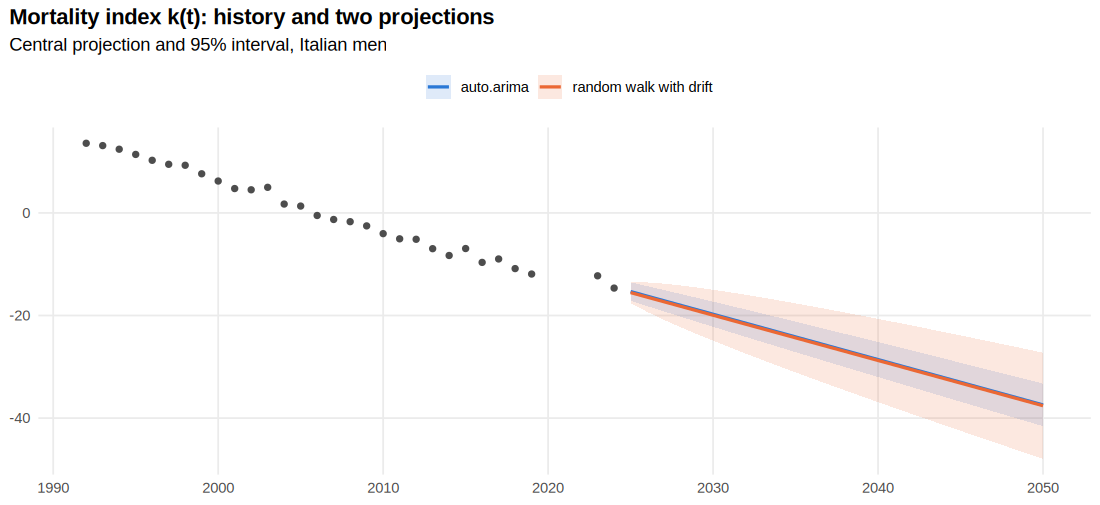

In [8]:
proj_years <- (max(years) + 1):2050
bands <- rbind(data.frame(year = proj_years, mean = rw_mean, lo = rw_lo, hi = rw_hi, model = "random walk with drift"),
               data.frame(year = proj_years, mean = as.numeric(fc_arima$mean), lo = as.numeric(fc_arima$lower),
                          hi = as.numeric(fc_arima$upper), model = "auto.arima"))
ggplot() +
  geom_ribbon(data = bands, aes(year, ymin = lo, ymax = hi, fill = model), alpha = 0.15) +
  geom_line(data = bands, aes(year, mean, colour = model), linewidth = 1) +
  geom_point(data = data.frame(year = fit_years, k = k), aes(year, k), colour = "grey30", size = 1.6) +
  scale_colour_manual(values = COLORS[1:2]) + scale_fill_manual(values = COLORS[1:2]) +
  labs(title = "Mortality index k(t): history and two projections", subtitle = "Central projection and 95% interval, Italian men",
       x = NULL, y = NULL, colour = NULL, fill = NULL)

## 5. Conclusions

- Deaths, exposures, the Lee-Carter parameters, the random-walk drift and volatility and the period life expectancy computed in R agree
  with the Python package to numerical precision: the mortality basis does not depend on the implementation.
- The ARIMA model selected on the same data is compared with the random walk on the central path and on the high-longevity bound of the
  projection: the two differences printed in section 4 are a simple measure of trend model risk, to be considered alongside the
  uncertainty already simulated around the random walk. A model with a narrower interval would imply a lower longevity capital, so the
  choice of the trend model is itself a prudence decision.

### References

- Brouhns, N., Denuit, M. and Vermunt, J. K. (2002). A Poisson log-bilinear regression approach to the construction of projected lifetables. *Insurance: Mathematics and Economics*, 31(3), 373-393.
- Hyndman, R. J. and Khandakar, Y. (2008). Automatic time series forecasting: the forecast package for R. *Journal of Statistical Software*, 27(3).
- Lee, R. D. and Carter, L. R. (1992). Modeling and forecasting U.S. mortality. *Journal of the American Statistical Association*, 87(419), 659-671.
- Turner, H. and Firth, D. (2020). Generalized nonlinear models in R: an overview of the gnm package. R package vignette.